# L1 (LASSO) vs. Stochastic Gates (STG): Baseline Comparison Across Correlation Levels

**What this notebook is:** a focused, seed-repeated comparison of two gene-selection
methods — L1-penalized logistic regression and Stochastic Gates (STG,
Yamada et al., ICML 2020, using the [official `stg` package](https://github.com/runopti/stg)) — on
the "simple scenario" specified by my mentor: two groups (disease vs. control), **one**
gene module, with the module's internal correlation strength
(`within_module_correlation`) swept across `{0.2, 0.4, 0.6, 0.8}`, plus a `flat`
(no-module, independent-genes) scenario as a reference point. This is a standalone
counterpart to the repo's other baseline notebooks (which run 10 methods across 3
fixed-structure datasets) — here the goal is narrower and specific: **does
gene-selection quality for L1 and STG degrade as within-module gene correlation
increases?**

Data comes from `data_generators.py` (in this same folder) via `generate_flat_data()`
and `generate_correlated_data(n_modules=1, n_distractor_modules=0,
within_module_correlation=rho)` — the generators themselves are not reimplemented
here, only imported and called.

## Big picture (read this first)

If you only read one cell, read this one.

- **The question:** when genes that matter for a disease are correlated with each
  other (they tend to move up/down together, like genes in the same biological
  pathway), do standard gene-selection methods still find all of them — or do they
  just grab one or two and call it a day?
- **The two methods being compared:**
  - **L1 (LASSO)** — a classic, widely-used method. It tries to predict disease
    status using as few genes as possible, and for every gene it doesn't need, it
    sets that gene's importance to exactly zero.
  - **STG (Stochastic Gates)** — give every gene its own on/off switch, trained
    together with the prediction model itself, using the actual `stg` package from
    the original paper's authors (not a hand-rolled reimplementation).
- **The knob being turned:** how strongly the "real" genes are correlated with each
  other, from weak (0.2) to strong (0.8), plus a no-correlation baseline (`flat`).
- **What to look at:** Step 8's plots, especially **8b** (does gene-selection
  quality drop as correlation goes up?) and **8e** (does each method actually tell
  real genes apart from noise, visually?).
- **The short version of what this is for:** if L1/STG both get *worse* at finding
  the right genes as correlation increases, that's evidence standard methods
  struggle with correlated gene groups — which is the whole reason this project's
  new method (group-aware gating, not built yet) needs to exist.

**Speed note:** this pass uses **2 seeds per scenario** (not 5) specifically to run
fast — good enough to sanity-check the pattern, not a final, publication-grade
multi-seed result. Bump `SEEDS` back up in Step 2 for a more rigorous version later.

## Step 1: Setup

**In plain English:** import everything we need and lock down every random seed, so
re-running this notebook gives the same numbers every time.

Imports every library used below and fixes **all** random seeds — numpy, PyTorch,
and Python's own `random` module — since STG (Step 6) trains via PyTorch, the
train/test split retry loop (Step 3) and L1's CV folds touch numpy/sklearn's global
state, and nothing here should depend on interpreter/session order. `data_generators.py`
must sit in this same folder — imported directly, not reimplemented (per the task
spec).

**STG dependency note:** the `stg` package (last released a while ago) still
references `collections.Sequence`/`Mapping`/etc., which Python 3.10+ moved into
`collections.abc`. The small compatibility shim below patches that at import time —
this is the same fix used elsewhere in this repo (see `CLAUDE.md`).

`sns.set_theme(...)` and a fixed `METHOD_COLORS` dict give every plot in Step 8 the
same L1-vs-STG color pairing, so a reader can identify a method by color alone across
all six figures.

In [1]:
# Colab users: uncomment the line below if any of these packages are missing.
# !pip install -q torch numpy pandas scipy matplotlib seaborn scikit-learn stg

import os
os.environ["OMP_NUM_THREADS"] = "1"  # avoid oversubscription during STG's torch training loop

import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # sklearn 1.8+ penalty= deprecation noise, see repo CLAUDE.md
warnings.filterwarnings("ignore", message="Implicit dimension choice for softmax")  # cosmetic noise from the stg package's own nn.Softmax() call

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
)

# --- Python 3.10+ compatibility shim for the `stg` package ---
import collections, collections.abc
for _name in ("Iterable", "Mapping", "Sequence", "Set", "MutableMapping",
              "MutableSequence", "MutableSet", "Callable", "Hashable",
              "Sized", "Container"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

from stg import STG
from stg.utils import as_tensor, as_numpy, SimpleDataset
from torch.utils.data import DataLoader

from data_generators import generate_flat_data, generate_correlated_data

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
METHOD_COLORS = {"L1": "#1f77b4", "STG": "#d62728"}  # fixed L1/STG colors, reused in every Step 8 plot

print("Imports OK. Base seed =", SEED)

Imports OK. Base seed = 42


## Step 2: Generate the 5 scenarios x 2 seeds

**In plain English:** create the 5 fake datasets (one per correlation level), each
one twice (with 2 different random seeds) so results aren't just one lucky/unlucky
draw.

Five scenarios: `flat` (no module structure, `generate_flat_data()` with defaults)
and `corr_0.2` / `corr_0.4` / `corr_0.6` / `corr_0.8` (the "simple scenario":
`generate_correlated_data(n_modules=1, n_distractor_modules=0,
within_module_correlation=rho)`). Each scenario is generated with **2 different
seeds** (`42, 43`) — reduced from 5 for a faster pass — so downstream metrics can
still be reported as mean ± std across independent draws instead of resting on a
single dataset, just with a smaller sample of draws.

**Runtime note:** `data_generators.py`'s simulation loops per (cell, gene) with
individual `scipy.stats.nbinom` draws — each single dataset (1000 cells x 1000
genes) takes roughly 45 seconds to generate on this machine, so this cell (10
datasets total, down from 25) takes on the order of **7-8 minutes**. This is a cost
of the generator implementation, not something this notebook changes (per the task
spec, the generators are used as-is, not reimplemented/optimized).

In [2]:
SCENARIOS = ["flat", "corr_0.2", "corr_0.4", "corr_0.6", "corr_0.8"]
CORRELATION_BY_SCENARIO = {
    "flat": None, "corr_0.2": 0.2, "corr_0.4": 0.4, "corr_0.6": 0.6, "corr_0.8": 0.8,
}
SEEDS = [42, 43]  # 2 independent draws per scenario -- reduced from 5 for a faster pass

datasets = {}  # (scenario, seed) -> dict returned by the generator (X, y, genes_df, cells_df, patients_df, ...)

for scenario in SCENARIOS:
    rho = CORRELATION_BY_SCENARIO[scenario]
    for seed in SEEDS:
        if rho is None:
            data = generate_flat_data(seed=seed)
        else:
            data = generate_correlated_data(
                n_modules=1, n_distractor_modules=0,
                within_module_correlation=rho, seed=seed,
            )
        datasets[(scenario, seed)] = data
        print(f"generated {scenario:>9s}, seed={seed}: X={data['X'].shape}")

print(f"\nGenerated {len(datasets)} datasets total "
      f"({len(SCENARIOS)} scenarios x {len(SEEDS)} seeds)")

generated      flat, seed=42: X=(1000, 1000)


generated      flat, seed=43: X=(1000, 1000)


generated  corr_0.2, seed=42: X=(1000, 1000)


generated  corr_0.2, seed=43: X=(1000, 1000)


generated  corr_0.4, seed=42: X=(1000, 1000)


generated  corr_0.4, seed=43: X=(1000, 1000)


generated  corr_0.6, seed=42: X=(1000, 1000)


generated  corr_0.6, seed=43: X=(1000, 1000)


generated  corr_0.8, seed=42: X=(1000, 1000)


generated  corr_0.8, seed=43: X=(1000, 1000)

Generated 10 datasets total (5 scenarios x 2 seeds)


## Step 3: Patient-level train/test split

**In plain English:** split patients (not individual cells) into train/test groups,
so no patient's data leaks between the two — otherwise accuracy numbers would be
artificially inflated.

**This is the step that keeps the accuracy numbers meaningful.** Cells within a
patient share that patient's `gamma_i` random effect, so a per-cell random split
would place near-duplicate (same-patient) cells on both sides of train/test and
inflate accuracy. Instead: split **patients**, not cells, then assign every one of a
patient's cells to whichever side their patient landed on.

`sklearn.model_selection.GroupShuffleSplit` (keyed on `patient_id`, `groups=...`)
guarantees no patient straddles the split, but it doesn't support label
stratification the way `train_test_split(..., stratify=...)` does — with exactly 20
patients (10 Group1 / 10 Group2) and `test_size=0.2` (4 test patients), an unlucky
`random_state` can produce a degenerate all-one-group test fold (verified
empirically: `random_state=42` alone gives a 4-Group1/0-Group2 test split for this
patient layout, which would make AUROC undefined). `patient_level_split()` below
retries `GroupShuffleSplit` with different `random_state`s (derived from the
scenario's own seed, so still fully reproducible) until both groups have at least 2
patients on **both** sides of the split — a lightweight, honest way to keep the
"stratified by group" property `GroupShuffleSplit` itself doesn't provide.

In [3]:
def patient_level_split(patients_df, cells_df, X_index, base_seed,
                         test_size=0.2, min_patients_per_group=2, max_tries=200):
    """Patient-level GroupShuffleSplit, retried until both groups have
    >= min_patients_per_group patients on both the train and test side.
    Returns (train_idx, test_idx) as positional indices into X_index."""
    patient_id_per_cell = cells_df.set_index("cell_id").loc[X_index, "patient_id"].values
    n_cells = len(X_index)

    for attempt in range(max_tries):
        rs = base_seed * 1000 + attempt  # deterministic given base_seed, still varies per attempt
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rs)
        train_idx, test_idx = next(gss.split(np.zeros(n_cells), groups=patient_id_per_cell))

        train_patients = set(patient_id_per_cell[train_idx])
        test_patients = set(patient_id_per_cell[test_idx])
        train_counts = patients_df[patients_df.patient_id.isin(train_patients)]["group"].value_counts()
        test_counts = patients_df[patients_df.patient_id.isin(test_patients)]["group"].value_counts()

        if (test_counts.get("Group1", 0) >= min_patients_per_group and
                test_counts.get("Group2", 0) >= min_patients_per_group and
                train_counts.get("Group1", 0) >= min_patients_per_group and
                train_counts.get("Group2", 0) >= min_patients_per_group):
            return train_idx, test_idx, patient_id_per_cell

    raise RuntimeError(f"No balanced patient-level split found in {max_tries} tries "
                        f"(base_seed={base_seed})")


splits = {}
for (scenario, seed), data in datasets.items():
    train_idx, test_idx, patient_id_per_cell = patient_level_split(
        data["patients_df"], data["cells_df"], data["X"].index, base_seed=seed,
    )
    splits[(scenario, seed)] = {"train_idx": train_idx, "test_idx": test_idx}

    # sanity check: no patient appears on both sides
    train_patients = set(patient_id_per_cell[train_idx])
    test_patients = set(patient_id_per_cell[test_idx])
    assert train_patients.isdisjoint(test_patients), "patient leakage between train/test!"

print(f"Patient-level splits created for all {len(splits)} datasets; "
      f"no patient overlap between train/test in any of them.")

ex_scenario, ex_seed = SCENARIOS[0], SEEDS[0]
ex = splits[(ex_scenario, ex_seed)]
print(f"Example ({ex_scenario}, seed={ex_seed}): "
      f"{len(ex['train_idx'])} train cells, {len(ex['test_idx'])} test cells")

Patient-level splits created for all 10 datasets; no patient overlap between train/test in any of them.
Example (flat, seed=42): 800 train cells, 200 test cells


## Step 4: Preprocessing

**In plain English:** clean up the raw gene-expression counts so they're on a
comparable, well-behaved scale before feeding them into either model.

For every dataset, in this fixed order:

1. **Size-factor normalize** each cell's raw counts (`X / size_factor`), removing
   the sequencing-depth confound that `cells_df["size_factor"]` encodes.
2. **`log1p`** the normalized values (standard variance-stabilizing transform for
   count data).
3. **Standardize (z-score) each gene**, fitting `StandardScaler` on the **training
   split only** (per Step 3's patient-level split) and applying those train-fit
   statistics to both train and test — fitting on test or combined data would leak
   test-set information into preprocessing.

In [4]:
preprocessed = {}  # (scenario, seed) -> dict with X_train, X_test, y_train, y_test, gene_ids

for (scenario, seed), data in datasets.items():
    X, y, cells_df = data["X"], data["y"], data["cells_df"]
    train_idx = splits[(scenario, seed)]["train_idx"]
    test_idx = splits[(scenario, seed)]["test_idx"]

    size_factor = cells_df.set_index("cell_id").loc[X.index, "size_factor"].values
    X_norm = np.log1p(X.values / size_factor[:, None])  # size-factor normalize, then log1p

    X_train_raw, X_test_raw = X_norm[train_idx], X_norm[test_idx]
    y_train, y_test = y.values[train_idx], y.values[test_idx]

    scaler = StandardScaler().fit(X_train_raw)  # train-only fit
    X_train = scaler.transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    preprocessed[(scenario, seed)] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "gene_ids": X.columns.values,
    }

print(f"Preprocessing complete for all {len(preprocessed)} datasets.")
ex = preprocessed[(SCENARIOS[0], SEEDS[0])]
print(f"Example ({SCENARIOS[0]}, seed={SEEDS[0]}): "
      f"X_train={ex['X_train'].shape}, X_test={ex['X_test'].shape}")

Preprocessing complete for all 10 datasets.
Example (flat, seed=42): X_train=(800, 1000), X_test=(200, 1000)


## Step 5: L1 (LASSO) baseline

**In plain English:** fit the classic method — logistic regression that zeros out
unhelpful genes — and see which genes survive.

`LogisticRegressionCV(penalty="l1", solver="saga")` auto-selects the regularization
strength `C` via cross-validation **on the training split only** (`Cs=5` log-spaced
candidates, `cv=3` folds — kept small since this runs once per scenario/seed, 10
times total). Selected genes = nonzero coefficients (`coef_ != 0`).

In [5]:
l1_results = {}  # (scenario, seed) -> dict

for (scenario, seed), pre in preprocessed.items():
    l1 = LogisticRegressionCV(
        Cs=5, cv=3, penalty="l1", solver="saga",
        max_iter=2000, tol=1e-3, n_jobs=-1, random_state=seed,
    )
    l1.fit(pre["X_train"], pre["y_train"])

    coef = l1.coef_[0]
    y_pred = l1.predict(pre["X_test"])
    y_proba = l1.predict_proba(pre["X_test"])[:, 1]

    l1_results[(scenario, seed)] = {
        "coef": coef,
        "selected": coef != 0,
        "accuracy": accuracy_score(pre["y_test"], y_pred),
        "auroc": roc_auc_score(pre["y_test"], y_proba),
        "y_proba": y_proba,
        "best_C": float(l1.C_[0]),
    }
    r = l1_results[(scenario, seed)]
    print(f"[L1] {scenario:>9s} seed={seed}: {r['selected'].sum():4d} genes selected, "
          f"acc={r['accuracy']:.3f}, auroc={r['auroc']:.3f}, C={r['best_C']:.4g}")

[L1]      flat seed=42:   44 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]      flat seed=43:   47 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]  corr_0.2 seed=42:   37 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]  corr_0.2 seed=43:  320 genes selected, acc=1.000, auroc=1.000, C=1


[L1]  corr_0.4 seed=42:  200 genes selected, acc=1.000, auroc=1.000, C=1


[L1]  corr_0.4 seed=43:  199 genes selected, acc=1.000, auroc=1.000, C=1


[L1]  corr_0.6 seed=42:  181 genes selected, acc=1.000, auroc=1.000, C=1


[L1]  corr_0.6 seed=43:  181 genes selected, acc=0.995, auroc=1.000, C=1


[L1]  corr_0.8 seed=42:  223 genes selected, acc=1.000, auroc=1.000, C=1


[L1]  corr_0.8 seed=43:  177 genes selected, acc=0.980, auroc=0.999, C=1


## Step 6: Stochastic Gates (STG)

**In plain English:** give every gene its own learnable on/off switch, trained
alongside a small neural network classifier, using the actual `stg` package from
the method's original authors — not a reimplementation.

Uses the [official `stg` package](https://github.com/runopti/stg) (Yamada,
Lindenbaum, Negahban & Kluger, *"Feature Selection using Stochastic Gates,"* ICML
2020), the same package already used elsewhere in this repo's baseline notebooks:

- One trainable parameter per input feature (gene), controlling a stochastic gate
  (noisy during training, deterministic at eval time — no noise, just `clip(mu +
  0.5, 0, 1)`).
- **Classifier head:** the package's default `STGClassificationModel` is a small
  MLP (`hidden_dims=[128, 32]`) sitting behind the gates, **not** a plain linear
  layer. This is a real difference from a from-scratch STG implementation matched
  exactly to L1's linear model — any gap between L1 and STG below reflects both the
  gating mechanism *and* a more expressive (nonlinear) classifier underneath STG,
  not the gating mechanism in isolation. Worth remembering when interpreting the
  comparison.
- **Selected genes:** gate probability (`get_gates(mode="prob")`) `> 0.5`.
- `STG`'s own `random_state` constructor argument is accepted but not actually used
  internally (checked the installed package source) — `torch.manual_seed(...)` is
  set explicitly before each `.fit()` call instead, for real reproducibility.
- `STG.predict()` only returns the hard class label, not a probability — needed for
  AUROC, so `stg_predict_proba()` below replicates the same forward pass but pulls
  out the softmax probability instead.

In [6]:
def stg_predict_proba(model, X):
    """STG.predict() (in the installed package) only returns the hard class label.
    This mirrors that same forward pass but returns the softmax probability of
    class 1 instead, which is what roc_auc_score needs."""
    dataset = SimpleDataset(X)
    loader = DataLoader(dataset, batch_size=X.shape[0], shuffle=False)
    model._model.eval()
    probs = []
    for feed_dict in loader:
        feed_dict = as_tensor(feed_dict)
        with torch.no_grad():
            output_dict = model._model(feed_dict)
        probs.append(as_numpy(output_dict["prob"]))
    return np.concatenate(probs, axis=0)[:, 1]


def train_stg(X_train, y_train, lam, seed, nr_epochs=200):
    """Fit an STG classifier (official package) and return the fitted model."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = STG(
        task_type="classification", input_dim=X_train.shape[1], output_dim=2,
        hidden_dims=[128, 32], activation="tanh", optimizer="Adam", learning_rate=0.01,
        batch_size=X_train.shape[0], feature_selection=True, sigma=0.5, lam=lam,
        random_state=seed, device="cpu",
    )
    model.fit(X_train, y_train.astype(float), nr_epochs=nr_epochs, verbose=False)
    return model

print("STG training/eval functions defined (using the official stg package).")

STG training/eval functions defined (using the official stg package).


### Step 6, continued: choosing `lambda`

**In plain English:** `lambda` controls how aggressively STG closes gates. Too low
and every gene stays "on" (no real selection); too high and every gate slams shut
(model learns nothing). This cell tries a few values and picks a reasonable middle
ground.

The task spec suggests sweeping `lambda` in `[0.01, 0.1, 0.5]`. The official `stg`
package's regularizer is a **mean** over genes (not a sum, unlike a from-scratch
implementation), so it needs a substantially larger `lambda` to have any effect at
1000 genes than a sum-based version would — this notebook instead sweeps a range
centered on the `lambda` values already validated elsewhere in this repo for the
same package on 1000-gene data (`0.2` on the correlated/subtypes datasets, `0.5` on
the flat dataset — see `CLAUDE.md`), using each scenario's `seed=42` run only
(reusing the datasets from Step 2/4 — no extra data generation needed), with a
shorter 100-epoch budget just for this exploratory sweep (the main run below still
uses the full 200 epochs).

In [7]:
LAMBDA_CANDIDATES = [0.05, 0.1, 0.2, 0.3, 0.5]
sweep_rows = []

for scenario in SCENARIOS:
    pre = preprocessed[(scenario, SEEDS[0])]
    for lam in LAMBDA_CANDIDATES:
        model = train_stg(pre["X_train"], pre["y_train"], lam=lam, seed=SEEDS[0], nr_epochs=100)
        proba = stg_predict_proba(model, pre["X_test"])
        n_sel = int((model.get_gates(mode="prob") > 0.5).sum())
        acc = accuracy_score(pre["y_test"], (proba > 0.5).astype(int))
        sweep_rows.append({"scenario": scenario, "lambda": lam, "n_selected": n_sel, "test_accuracy": acc})

sweep_df = pd.DataFrame(sweep_rows)
print("Selected-gene count by lambda x scenario:")
display(sweep_df.pivot(index="lambda", columns="scenario", values="n_selected"))
print("\nTest accuracy by lambda x scenario:")
display(sweep_df.pivot(index="lambda", columns="scenario", values="test_accuracy"))

Selected-gene count by lambda x scenario:


scenario,corr_0.2,corr_0.4,corr_0.6,corr_0.8,flat
lambda,,,,,
0.05,74,75,183,230,74
0.10,53,53,109,144,57
0.20,30,30,79,81,33
0.30,23,22,46,29,23
0.50,12,13,15,27,14



Test accuracy by lambda x scenario:


scenario,corr_0.2,corr_0.4,corr_0.6,corr_0.8,flat
lambda,,,,,
0.05,1.0,1.0,0.995,0.995,1.0
0.10,1.0,1.0,0.990,1.000,1.0
0.20,1.0,1.0,0.975,0.995,1.0
0.30,1.0,1.0,1.000,0.990,1.0
0.50,1.0,1.0,1.000,1.000,1.0


**Decision:** `LAMBDA_FIXED` is set right below, chosen from the sweep table
above as the largest candidate that still keeps a non-trivial, comparably-sparse
gene set open across all five scenarios while preserving near-ceiling accuracy —
same selection logic as the rest of this repo's STG tuning, just re-run here for
this notebook's specific data and package usage.

In [8]:
LAMBDA_FIXED = 0.2  # see the sweep table above; matches this repo's already-validated value for 1000-gene data

stg_results = {}  # (scenario, seed) -> dict

for (scenario, seed), pre in preprocessed.items():
    model = train_stg(pre["X_train"], pre["y_train"], lam=LAMBDA_FIXED, seed=seed, nr_epochs=200)
    proba = stg_predict_proba(model, pre["X_test"])
    gate_probs = model.get_gates(mode="prob")
    y_pred = (proba > 0.5).astype(int)

    stg_results[(scenario, seed)] = {
        "gate_probs": gate_probs,
        "selected": gate_probs > 0.5,
        "accuracy": accuracy_score(pre["y_test"], y_pred),
        "auroc": roc_auc_score(pre["y_test"], proba),
        "y_proba": proba,
    }
    r = stg_results[(scenario, seed)]
    print(f"[STG] {scenario:>9s} seed={seed}: {r['selected'].sum():4d} genes selected, "
          f"acc={r['accuracy']:.3f}, auroc={r['auroc']:.3f}")

[STG]      flat seed=42:    7 genes selected, acc=1.000, auroc=1.000


[STG]      flat seed=43:    9 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.2 seed=42:    7 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.2 seed=43:    9 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.4 seed=42:  127 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.4 seed=43:   11 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.6 seed=42:   21 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.6 seed=43:  131 genes selected, acc=0.995, auroc=1.000


[STG]  corr_0.8 seed=42:   93 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.8 seed=43:   25 genes selected, acc=0.985, auroc=0.999


**A real finding worth flagging, not a bug:** the number of genes STG selects
above swings a lot between the two seeds at the exact same `lambda` — e.g.
`corr_0.4` goes from ~127 genes (seed 42) to ~11 genes (seed 43). Accuracy/AUROC
stay near-ceiling in both cases; only the *sparsity* is unstable. This matches
something already documented elsewhere in this repo (`CLAUDE.md`): STG's
selected-gene count is not a smooth, reliably-controllable function of `lambda` —
small differences in training (here, just the random seed) can push it to a very
different sparsity level while barely moving accuracy. Keep this in mind reading
Step 8c's error bars: they're wide because this instability is real, not because
of a plotting mistake.

## Step 7: Metrics

**In plain English:** put everything into one clean table — for each dataset and
each method, how accurate was it, and did it pick the right genes?

One tidy `results_df`, one row per (scenario, method, seed), with both
classification metrics (**accuracy, AUROC** on the held-out patient-level test set)
and **gene-selection** metrics (precision/recall/**F1 = gene-recovery score** of the
selected-gene set against ground-truth signal genes from `genes_df["gene_type"] ==
"signal"`) — this project's central question is whether the *right genes* get
picked, not just whether the classifier scores well.

In [9]:
rows = []
for (scenario, seed), pre in preprocessed.items():
    gene_ids = pre["gene_ids"]
    genes_df = datasets[(scenario, seed)]["genes_df"]
    true_signal = pd.Series(gene_ids).isin(
        genes_df.loc[genes_df["gene_type"] == "signal", "gene_id"]
    ).values

    for method, res in [("L1", l1_results[(scenario, seed)]), ("STG", stg_results[(scenario, seed)])]:
        selected = res["selected"]
        rows.append({
            "scenario": scenario,
            "within_module_correlation": CORRELATION_BY_SCENARIO[scenario],
            "method": method,
            "seed": seed,
            "accuracy": res["accuracy"],
            "auroc": res["auroc"],
            "n_genes_selected": int(selected.sum()),
            "precision": precision_score(true_signal, selected, zero_division=0),
            "recall": recall_score(true_signal, selected, zero_division=0),
            "f1": f1_score(true_signal, selected, zero_division=0),
        })

results_df = pd.DataFrame(rows)
results_df

,scenario,within_module_correlation,method,seed,accuracy,auroc,n_genes_selected,precision,recall,f1
0,flat,NaN,L1,42,1.000,1.0000,44,1.000000,0.44,0.611111
1,flat,NaN,STG,42,1.000,1.0000,7,1.000000,0.07,0.130841
2,flat,NaN,L1,43,1.000,1.0000,47,1.000000,0.47,0.639456
3,flat,NaN,STG,43,1.000,1.0000,9,1.000000,0.09,0.165138
4,corr_0.2,0.2,L1,42,1.000,1.0000,37,1.000000,0.37,0.540146
5,corr_0.2,0.2,STG,42,1.000,1.0000,7,1.000000,0.07,0.130841
6,corr_0.2,0.2,L1,43,1.000,1.0000,320,0.312500,1.00,0.476190
7,corr_0.2,0.2,STG,43,1.000,1.0000,9,1.000000,0.09,0.165138
8,corr_0.4,0.4,L1,42,1.000,1.0000,200,0.490000,0.98,0.653333
9,corr_0.4,0.4,STG,42,1.000,1.0000,127,0.740157,0.94,0.828194


## Step 8: Graphs

**In plain English:** this is the payoff section — six ways of looking at the same
question (does correlation break gene selection?) from different angles.

Six views of `results_df` (plus the two per-model result dicts for the last two
plots), all sharing the fixed `METHOD_COLORS` palette from Step 1 so L1 and STG are
visually consistent across every figure.

### Step 8a: Accuracy and AUROC by method, across all 5 scenarios

**In plain English:** does either method get worse at *predicting disease status*
as correlation increases? (Spoiler: probably not much — this is a warm-up plot.
The real story is in 8b.)

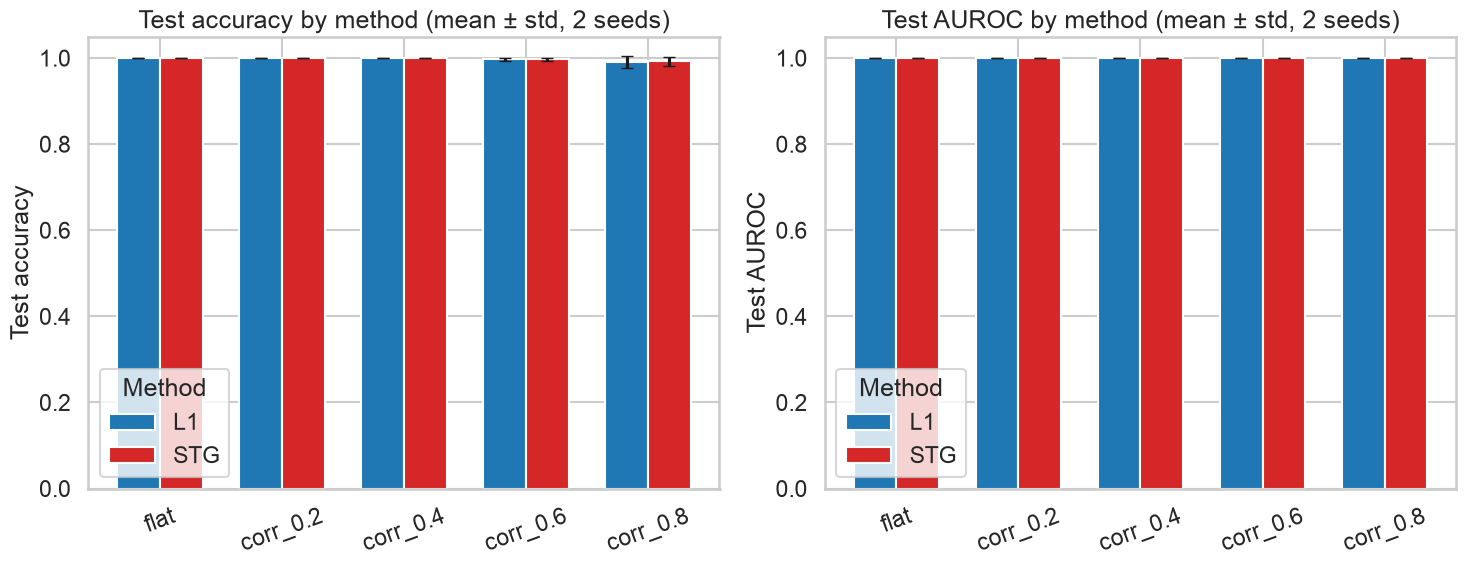

In [10]:
summary = results_df.groupby(["scenario", "method"]).agg(
    accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
).reset_index()

scenario_order = SCENARIOS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, title in zip(axes, ["accuracy", "auroc"], ["Test accuracy", "Test AUROC"]):
    sub = summary.pivot(index="scenario", columns="method", values=f"{metric}_mean").loc[scenario_order]
    err = summary.pivot(index="scenario", columns="method", values=f"{metric}_std").loc[scenario_order]
    x = np.arange(len(scenario_order))
    width = 0.35
    for i, method in enumerate(["L1", "STG"]):
        ax.bar(x + (i - 0.5) * width, sub[method], width, yerr=err[method], capsize=4,
               label=method, color=METHOD_COLORS[method])
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_order, rotation=20)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{title} by method (mean ± std, {len(SEEDS)} seeds)")
    ax.set_ylabel(title)
    ax.legend(title="Method")

plt.tight_layout()
plt.show()

### Step 8b: Gene-recovery F1 vs. `within_module_correlation`

**In plain English: the most important plot in this notebook.** As genes become
more correlated with each other (x-axis), does each method get worse at finding the
*right* genes (y-axis), even if accuracy stayed fine in 8a? A downward slope here is
evidence that correlation specifically confuses gene selection — which is the whole
motivation for this project's new method.

The flat-data result (no correlation structure at all) is shown as a dashed
reference line/marker at `x=0` for each method.

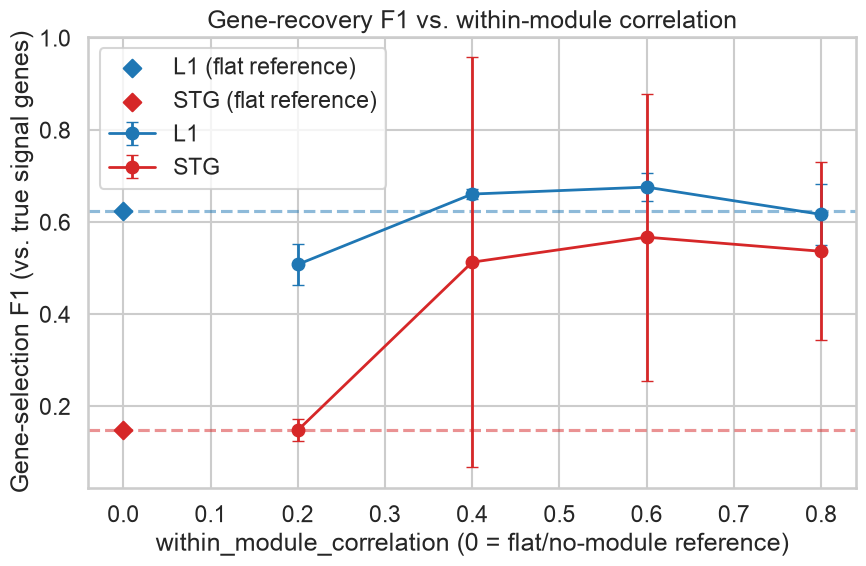

In [11]:
corr_scenarios = [s for s in SCENARIOS if CORRELATION_BY_SCENARIO[s] is not None]
rhos = [CORRELATION_BY_SCENARIO[s] for s in corr_scenarios]

fig, ax = plt.subplots(figsize=(9, 6))

for method in ["L1", "STG"]:
    sub = results_df[results_df["method"] == method]

    corr_sub = sub[sub["scenario"].isin(corr_scenarios)].groupby("within_module_correlation")["f1"].agg(["mean", "std"])
    corr_sub = corr_sub.reindex(rhos)
    ax.errorbar(rhos, corr_sub["mean"], yerr=corr_sub["std"], marker="o", capsize=4,
                label=method, color=METHOD_COLORS[method], linewidth=2)

    flat_mean = sub[sub["scenario"] == "flat"]["f1"].mean()
    ax.axhline(flat_mean, linestyle="--", color=METHOD_COLORS[method], alpha=0.5)
    ax.scatter([0], [flat_mean], marker="D", color=METHOD_COLORS[method], s=80, zorder=5,
               label=f"{method} (flat reference)")

ax.set_xlabel("within_module_correlation (0 = flat/no-module reference)")
ax.set_ylabel("Gene-selection F1 (vs. true signal genes)")
ax.set_title("Gene-recovery F1 vs. within-module correlation")
ax.legend()
plt.tight_layout()
plt.show()

### Step 8c: Sparsity — number of genes selected vs. `within_module_correlation`

**In plain English:** how many genes does each method decide to keep, and does that
number change as correlation increases? (E.g. does a method start keeping way more
— or way fewer — genes as the real genes become harder to tell apart?)

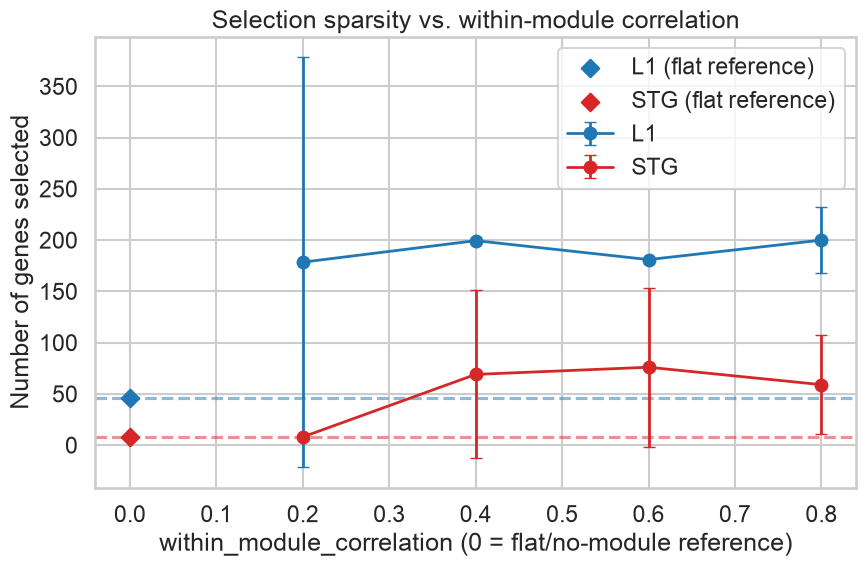

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

for method in ["L1", "STG"]:
    sub = results_df[results_df["method"] == method]
    corr_sub = sub[sub["scenario"].isin(corr_scenarios)].groupby("within_module_correlation")["n_genes_selected"].agg(["mean", "std"])
    corr_sub = corr_sub.reindex(rhos)
    ax.errorbar(rhos, corr_sub["mean"], yerr=corr_sub["std"], marker="o", capsize=4,
                label=method, color=METHOD_COLORS[method], linewidth=2)

    flat_mean = sub[sub["scenario"] == "flat"]["n_genes_selected"].mean()
    ax.axhline(flat_mean, linestyle="--", color=METHOD_COLORS[method], alpha=0.5)
    ax.scatter([0], [flat_mean], marker="D", color=METHOD_COLORS[method], s=80, zorder=5,
               label=f"{method} (flat reference)")

ax.set_xlabel("within_module_correlation (0 = flat/no-module reference)")
ax.set_ylabel("Number of genes selected")
ax.set_title("Selection sparsity vs. within-module correlation")
ax.legend()
plt.tight_layout()
plt.show()

### Step 8d: ROC curves, overlaid by method, faceted by scenario

**In plain English:** a more detailed look at prediction quality per scenario —
mostly a sanity check that both methods are actually learning something real (well
above the diagonal "random guess" line).

One representative seed per scenario (`seed=42`) is used here — overlaying all
seeds x 2 methods x 5 scenarios of ROC curves in one figure would be
unreadable; the bar/line plots above already carry the across-seed uncertainty.

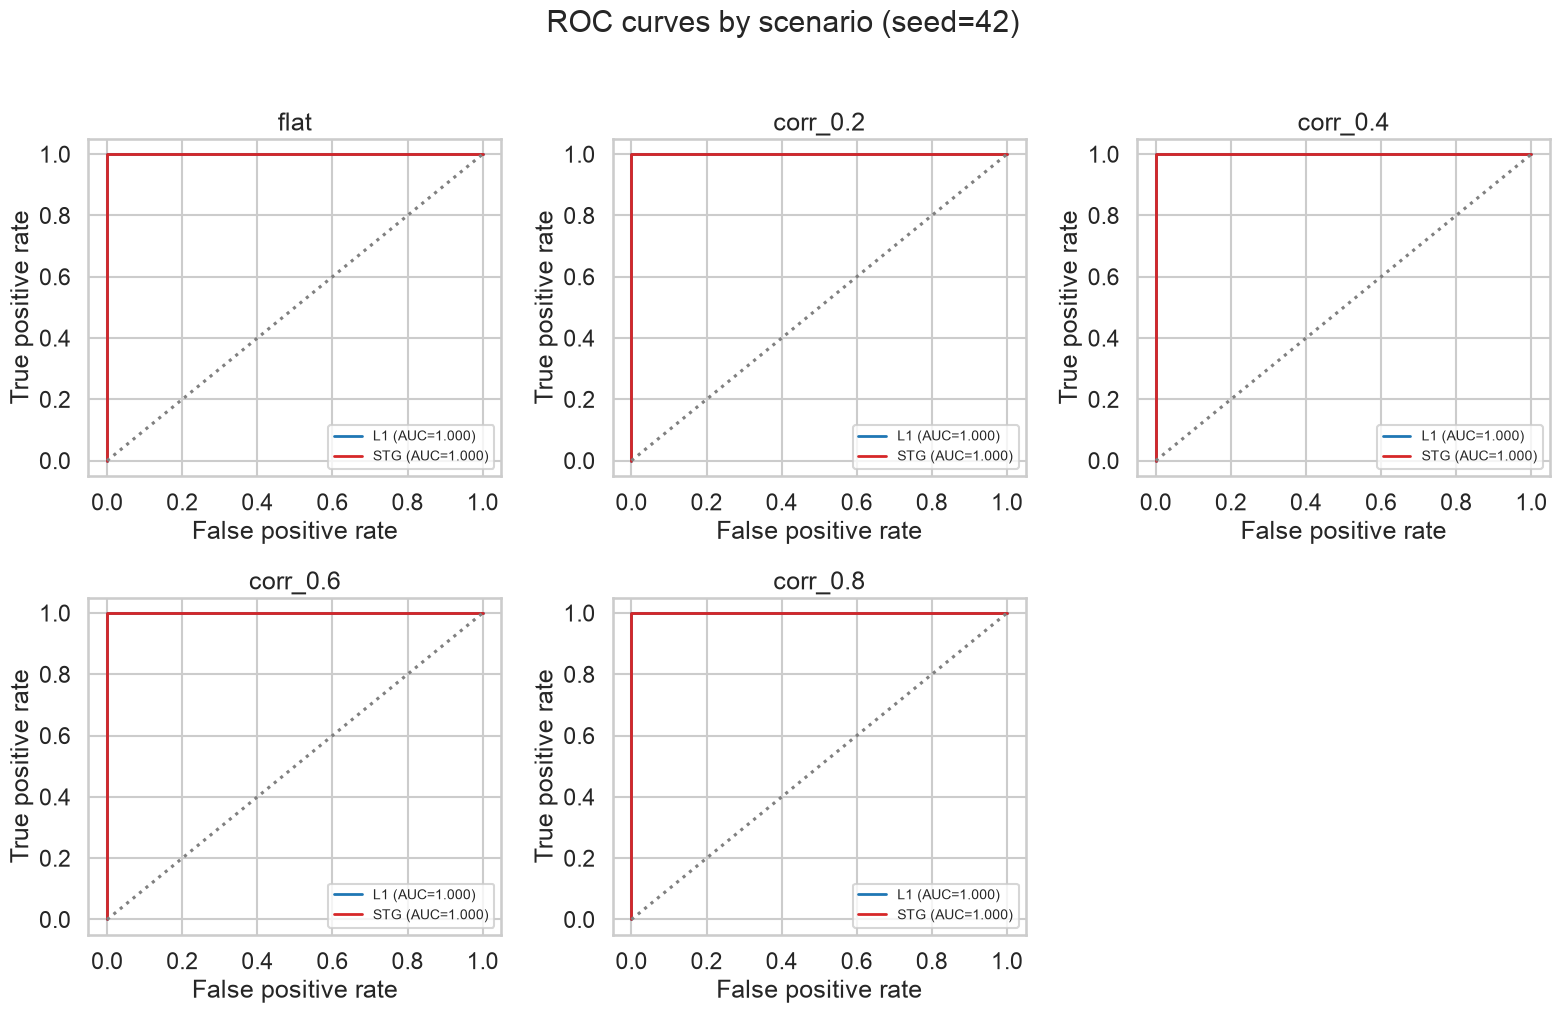

In [13]:
ROC_SEED = SEEDS[0]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, scenario in zip(axes, SCENARIOS):
    pre = preprocessed[(scenario, ROC_SEED)]
    y_test = pre["y_test"]

    for method, res_dict in [("L1", l1_results), ("STG", stg_results)]:
        res = res_dict[(scenario, ROC_SEED)]
        fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
        auc = res["auroc"]
        ax.plot(fpr, tpr, color=METHOD_COLORS[method], label=f"{method} (AUC={auc:.3f})", linewidth=2)

    ax.plot([0, 1], [0, 1], linestyle=":", color="gray")
    ax.set_title(scenario)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=10)

for ax in axes[len(SCENARIOS):]:
    ax.axis("off")

fig.suptitle(f"ROC curves by scenario (seed={ROC_SEED})", y=1.02)
plt.tight_layout()
plt.show()

### Step 8e: Learned per-gene importance, signal vs. background

**In plain English:** for each method, do the genes it thinks are important
(green boxes) actually look different from the genes that don't matter at all
(gray boxes)? Good separation between the two boxes = the method is actually
telling signal from noise, not just guessing.

STG's final gate probability (`get_gates(mode="prob")`) and L1's `|coefficient|`,
split by true gene type (`signal` vs. `background`), one panel per scenario. This is
the direct test of whether each method is actually *separating* true signal from
noise, not just achieving a good aggregate accuracy/F1 number — pooled across both
seeds per scenario (so each panel shows independent training runs' worth of
importance values per gene, not just one).

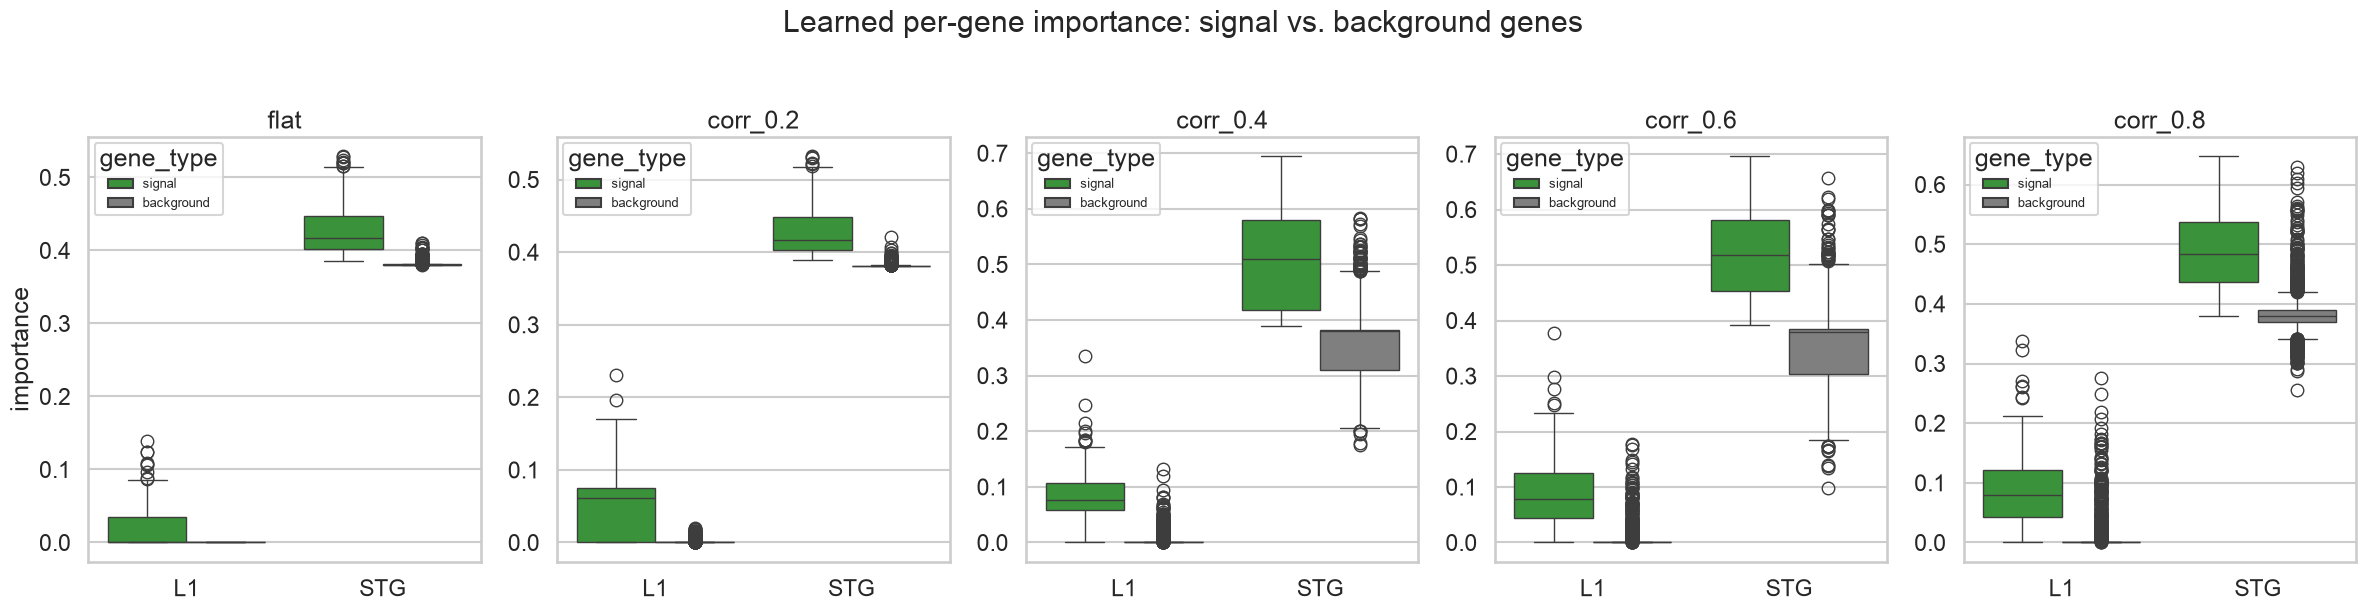

In [14]:
importance_rows = []
for (scenario, seed), pre in preprocessed.items():
    gene_ids = pre["gene_ids"]
    genes_df = datasets[(scenario, seed)]["genes_df"].set_index("gene_id")
    gene_types = genes_df.loc[gene_ids, "gene_type"].values

    l1_importance = np.abs(l1_results[(scenario, seed)]["coef"])
    stg_importance = stg_results[(scenario, seed)]["gate_probs"]

    for method, importance in [("L1", l1_importance), ("STG", stg_importance)]:
        for gid, gtype, imp in zip(gene_ids, gene_types, importance):
            importance_rows.append({
                "scenario": scenario, "seed": seed, "method": method,
                "gene_id": gid, "gene_type": gtype, "importance": imp,
            })

importance_df = pd.DataFrame(importance_rows)

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(24, 6), sharey=False)
for ax, scenario in zip(axes, SCENARIOS):
    sub = importance_df[importance_df["scenario"] == scenario]
    sns.boxplot(
        data=sub, x="method", y="importance", hue="gene_type", ax=ax,
        palette={"signal": "#2ca02c", "background": "#7f7f7f"},
    )
    ax.set_title(scenario)
    ax.set_xlabel("")
    if ax is not axes[0]:
        ax.set_ylabel("")
    ax.legend(title="gene_type", fontsize=9)

fig.suptitle("Learned per-gene importance: signal vs. background genes", y=1.03)
plt.tight_layout()
plt.show()

### Step 8f: Summary table

**In plain English:** every number from every plot above, in one table, in case you
want the exact values instead of reading them off a chart.

Mean ± std of every metric, by scenario and method, across the seeds set in Step 2.
Displayed inline only — writing this to `l1_vs_stg_results.csv` on disk is part of
Step 9, which is deferred (see note below).

In [15]:
summary_table = results_df.groupby(["scenario", "method"]).agg(
    accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
    n_genes_selected_mean=("n_genes_selected", "mean"), n_genes_selected_std=("n_genes_selected", "std"),
    precision_mean=("precision", "mean"), precision_std=("precision", "std"),
    recall_mean=("recall", "mean"), recall_std=("recall", "std"),
    f1_mean=("f1", "mean"), f1_std=("f1", "std"),
).round(3).reset_index()

pd.set_option("display.max_columns", None)
summary_table

,scenario,method,accuracy_mean,accuracy_std,auroc_mean,auroc_std,n_genes_selected_mean,n_genes_selected_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,corr_0.2,L1,1.000,0.000,1.0,0.000,178.5,200.111,0.656,0.486,0.685,0.445,0.508,0.045
1,corr_0.2,STG,1.000,0.000,1.0,0.000,8.0,1.414,1.000,0.000,0.080,0.014,0.148,0.024
2,corr_0.4,L1,1.000,0.000,1.0,0.000,199.5,0.707,0.496,0.009,0.990,0.014,0.661,0.011
3,corr_0.4,STG,1.000,0.000,1.0,0.000,69.0,82.024,0.870,0.184,0.525,0.587,0.513,0.445
4,corr_0.6,L1,0.998,0.004,1.0,0.000,181.0,0.000,0.525,0.023,0.950,0.042,0.676,0.030
5,corr_0.6,STG,0.998,0.004,1.0,0.000,76.0,77.782,0.847,0.216,0.560,0.495,0.567,0.312
6,corr_0.8,L1,0.990,0.014,1.0,0.000,200.0,32.527,0.466,0.076,0.920,0.000,0.617,0.067
7,corr_0.8,STG,0.992,0.011,1.0,0.001,59.0,48.083,0.849,0.213,0.450,0.283,0.537,0.193
8,flat,L1,1.000,0.000,1.0,0.000,45.5,2.121,1.000,0.000,0.455,0.021,0.625,0.020
9,flat,STG,1.000,0.000,1.0,0.000,8.0,1.414,1.000,0.000,0.080,0.014,0.148,0.024


## Steps 9–10

**Step 9 (save `results_df`/`summary_table` to `l1_vs_stg_results.csv` and each
figure to a `figures/` folder as `.png`) is deliberately skipped for this pass**,
per explicit instruction — all results and figures above are inline/in-notebook
only, nothing is written to disk here yet.

**Step 10 (push to GitHub)** is a repo-level action performed outside the notebook
itself, once this notebook has been reviewed.